In [1]:
import sys
import subprocess
import importlib
from tqdm import tqdm

REQUIRED = {
    "datasets": "datasets",
    "transformers": "transformers",
    "sklearn": "scikit-learn",
    "matplotlib": "matplotlib",
    "seaborn": "seaborn",
    "pandas": "pandas",
    "numpy": "numpy",
    "torch": "torch",
    "accelerate": "accelerate"
}

missing = []
print("🔍 Проверка установленных библиотек...")
for import_name, pip_name in REQUIRED.items():
    try:
        importlib.import_module(import_name)
        print(f"✅ {import_name:15} уже установлен")
    except ImportError:
        print(f"❌ {import_name:15} отсутствует")
        missing.append(pip_name)

if missing:
    print(f"\n📦 Начинаю установку {len(missing)} пакетов:")
    print("=" * 60)
    
    # Проходим по списку недостающих пакетов
    for pkg in tqdm(missing, desc="Общий прогресс", unit="pkg"):
        print(f"\n Установка {pkg}...")
        
        # ЗАПУСКАЕМ pip БЕЗ capture_output, чтобы видеть его прогресс-бар
        # Используем sys.executable чтобы ставить в текущую среду (Anaconda)
        subprocess.run([
            sys.executable, 
            "-m", "pip", 
            "install", 
            "--progress-bar", "on", 
            pkg
        ])
        
    print("\n" + "=" * 60)
    print("🎉 Установка завершена!")
    print("⚠️ ВАЖНО: Теперь перезапусти ядро (Kernel -> Restart) и запусти ноутбук заново.")
else:
    print("\n🎉 Все библиотеки уже установлены! Можно запускать код.")

🔍 Проверка установленных библиотек...
✅ datasets        уже установлен
✅ transformers    уже установлен
✅ sklearn         уже установлен
✅ matplotlib      уже установлен
✅ seaborn         уже установлен
✅ pandas          уже установлен
✅ numpy           уже установлен
✅ torch           уже установлен
✅ accelerate      уже установлен

🎉 Все библиотеки уже установлены! Можно запускать код.


Настройки сети: используем зеркало hf-mirror.com
Кэш Hugging Face: C:\Users\kuzne/.cache/huggingface
Using device: cuda

Загрузка датасета...
Попытка 1/3: загрузка датасета dair-ai/emotion...


Dataset sizes:
train: 16000
validation: 2000
test: 2000

Class names: ['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']

Sample examples:
Text: i didnt feel humiliated...
Label: sadness
------------------------------
Text: i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and ...
Label: sadness
------------------------------
Text: im grabbing a minute to post i feel greedy wrong...
Label: anger
------------------------------

Загрузка токенизатора: distilbert-base-uncased
Попытка 1/5: загрузка токенизатора distilbert-base-uncased...
Tokenization Demo:

Text: I am so happy today!
Tokens: ['[CLS]', 'i', 'am', 'so', 'happy', 'today', '!', '[SEP]']
Input IDs: [101, 1045, 2572, 2061, 3407, 2651, 999, 102]
Attention Mask: [1, 1, 1, 1, 1, 1, 1, 1]
Contains [CLS] token
Contains [SEP] token

Text: This is the worst experience ever.
Tokens: ['[CLS]', 'this', 'is', 'the', 'worst', 'experience', 'ever', '.', '[SEP]']
Input IDs: [101, 2023, 2003, 

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Модель для инференса загружена успешно

Zero-shot Inference (Pretrained Sentiment Model):
Text: I am so happy today!
Prediction: POSITIVE (1.00)
------------------------------
Text: I am terrified of the dark.
Prediction: NEGATIVE (1.00)
------------------------------
Text: This makes me angry.
Prediction: NEGATIVE (1.00)
------------------------------
Note: This model only predicts Positive/Negative, not specific emotions like Joy or Fear.

Токенизация датасета...

Загрузка модели для fine-tuning: distilbert-base-uncased
Попытка 1/5: загрузка модели distilbert-base-uncased...


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'loss': '0.1209', 'grad_norm': '0.2829', 'learning_rate': '6.34e-06', 'epoch': '2.05'}
{'loss': '0.1209', 'grad_norm': '0.2829', 'learning_rate': '6.34e-06', 'epoch': '2.05'}
{'loss': '0.106', 'grad_norm': '14.37', 'learning_rate': '6.007e-06', 'epoch': '2.1'}
{'loss': '0.106', 'grad_norm': '14.37', 'learning_rate': '6.007e-06', 'epoch': '2.1'}
{'loss': '0.105', 'grad_norm': '0.4551', 'learning_rate': '5.673e-06', 'epoch': '2.15'}
{'loss': '0.105', 'grad_norm': '0.4551', 'learning_rate': '5.673e-06', 'epoch': '2.15'}
{'loss': '0.08669', 'grad_norm': '13.5', 'learning_rate': '5.34e-06', 'epoch': '2.2'}
{'loss': '0.08669', 'grad_norm': '13.5', 'learning_rate': '5.34e-06', 'epoch': '2.2'}
{'loss': '0.1117', 'grad_norm': '8.54', 'learning_rate': '5.007e-06', 'epoch': '2.25'}
{'loss': '0.1117', 'grad_norm': '8.54', 'learning_rate': '5.007e-06', 'epoch': '2.25'}
{'loss': '0.09279', 'grad_norm': '1.179', 'learning_rate': '4.673e-06', 'epoch': '2.3'}
{'loss': '0.09279', 'grad_norm': '1.179', 

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


{'train_runtime': '370.1', 'train_samples_per_second': '129.7', 'train_steps_per_second': '8.106', 'train_loss': '0.2419', 'epoch': '3'}
{'train_runtime': '370.1', 'train_samples_per_second': '129.7', 'train_steps_per_second': '8.106', 'train_loss': '0.2419', 'epoch': '3'}

Evaluating on Test Set...
{'eval_loss': '0.1746', 'eval_accuracy': '0.9245', 'eval_f1_macro': '0.8748', 'eval_runtime': '3.728', 'eval_samples_per_second': '536.5', 'eval_steps_per_second': '33.53', 'epoch': '3'}
{'eval_loss': '0.1746', 'eval_accuracy': '0.9245', 'eval_f1_macro': '0.8748', 'eval_runtime': '3.728', 'eval_samples_per_second': '536.5', 'eval_steps_per_second': '33.53', 'epoch': '3'}
Test Accuracy: 0.9245
Test F1 Macro: 0.8748


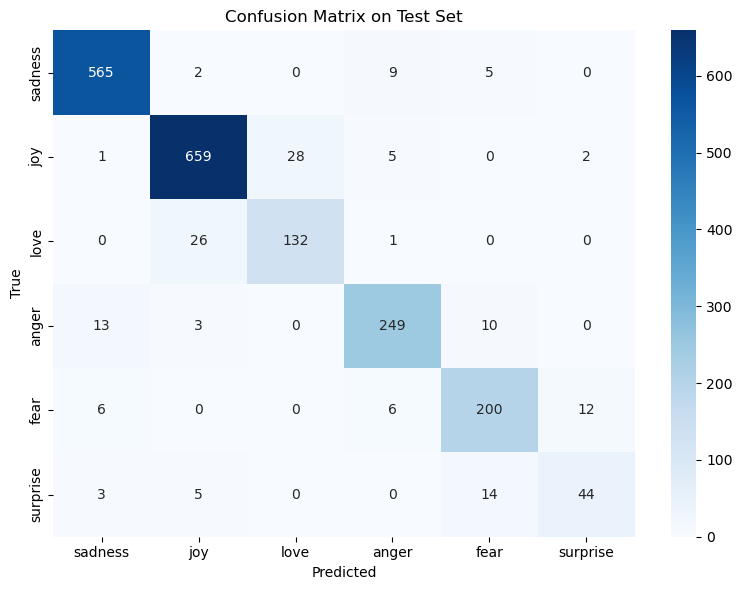

Saved artifacts/confusion_matrix.png
Saved artifacts/sample_predictions.csv

Error Analysis (First 5 misclassifications):
Text: i don t feel particularly agitated...
True: fear | Pred: anger
------------------------------
Text: i feel if i completely hated things i d exercise my democratic right speak my mi...
True: anger | Pred: sadness
------------------------------
Text: i feel a bit stressed even though all the things i have going on are fun...
True: anger | Pred: sadness
------------------------------
Text: i am right handed however i play billiards left handed naturally so me trying to...
True: surprise | Pred: fear
------------------------------
Text: i feel like i am in paradise kissing those sweet lips make me feel like i dive i...
True: joy | Pred: love
------------------------------

HW13 completed successfully!


In [2]:
import os
import sys
import time

os.environ["HF_ENDPOINT"] = "https://hf-mirror.com"
os.environ["HF_HUB_ENABLE_HF_TRANSFER"] = "0"
os.environ["HF_HUB_DOWNLOAD_TIMEOUT"] = "120"
os.environ["HF_HUB_ETAG_TIMEOUT"] = "30"

for var in ['http_proxy', 'https_proxy', 'all_proxy', 'HTTP_PROXY', 'HTTPS_PROXY', 'ALL_PROXY']:
    os.environ.pop(var, None)

print("Настройки сети: используем зеркало hf-mirror.com")
print(f"Кэш Hugging Face: {os.path.expanduser('~/.cache/huggingface')}")

import random
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns

from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer, pipeline
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

os.makedirs("artifacts", exist_ok=True)

def load_dataset_with_retry(dataset_name, max_retries=3, delay=10):
    for attempt in range(max_retries):
        try:
            print(f"Попытка {attempt+1}/{max_retries}: загрузка датасета {dataset_name}...")
            return load_dataset(dataset_name)
        except Exception as e:
            print(f"Попытка {attempt+1} не удалась: {type(e).__name__}: {e}")
            if attempt < max_retries - 1:
                wait_time = min(delay * (2 ** attempt), 60)
                print(f"Ждём {wait_time} секунд перед следующей попыткой...")
                time.sleep(wait_time)
            else:
                raise

def load_tokenizer_with_retry(model_name, max_retries=5, delay=10):
    for attempt in range(max_retries):
        try:
            print(f"Попытка {attempt+1}/{max_retries}: загрузка токенизатора {model_name}...")
            return AutoTokenizer.from_pretrained(model_name)
        except Exception as e:
            print(f"Попытка {attempt+1} не удалась: {type(e).__name__}: {e}")
            if attempt < max_retries - 1:
                wait_time = min(delay * (2 ** attempt), 60)
                print(f"Ждём {wait_time} секунд перед следующей попыткой...")
                time.sleep(wait_time)
            else:
                print(f"Пробуем загрузить из локального кэша...")
                try:
                    return AutoTokenizer.from_pretrained(model_name, local_files_only=True)
                except Exception as local_e:
                    print(f"Не удалось загрузить ни из интернета, ни из кэша.")
                    raise local_e

def load_model_with_retry(model_name, num_labels, max_retries=5, delay=10):
    for attempt in range(max_retries):
        try:
            print(f"Попытка {attempt+1}/{max_retries}: загрузка модели {model_name}...")
            return AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=num_labels)
        except Exception as e:
            print(f"Попытка {attempt+1} не удалась: {type(e).__name__}: {e}")
            if attempt < max_retries - 1:
                wait_time = min(delay * (2 ** attempt), 60)
                print(f"Ждём {wait_time} секунд перед следующей попыткой...")
                time.sleep(wait_time)
            else:
                print(f"Пробуем загрузить из локального кэша...")
                try:
                    return AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=num_labels, local_files_only=True)
                except Exception as local_e:
                    print(f"Не удалось загрузить ни из интернета, ни из кэша.")
                    raise local_e

print("\nЗагрузка датасета...")
dataset = load_dataset_with_retry("dair-ai/emotion", max_retries=3)

print("Dataset sizes:")
for split in dataset.keys():
    print(f"{split}: {len(dataset[split])}")

label_names = dataset["train"].features["label"].names
print(f"\nClass names: {label_names}")

print("\nSample examples:")
for i in range(3):
    item = dataset["train"][i]
    print(f"Text: {item['text'][:100]}...")
    print(f"Label: {label_names[item['label']]}")
    print("-" * 30)

model_name = "distilbert-base-uncased"
print(f"\nЗагрузка токенизатора: {model_name}")
tokenizer = load_tokenizer_with_retry(model_name, max_retries=5)

sample_texts = [
    "I am so happy today!",
    "This is the worst experience ever.",
    "I feel quite neutral about this."
]

print("Tokenization Demo:")
for text in sample_texts:
    enc = tokenizer(text, truncation=True, padding=True, max_length=10)
    print(f"\nText: {text}")
    print(f"Tokens: {tokenizer.convert_ids_to_tokens(enc['input_ids'])}")
    print(f"Input IDs: {enc['input_ids']}")
    print(f"Attention Mask: {enc['attention_mask']}")
    if tokenizer.cls_token in tokenizer.convert_ids_to_tokens(enc['input_ids']):
        print("Contains [CLS] token")
    if tokenizer.sep_token in tokenizer.convert_ids_to_tokens(enc['input_ids']):
        print("Contains [SEP] token")

print("\nЗагрузка готовой модели для инференса (SST-2)...")
sentiment_model_name = "distilbert-base-uncased-finetuned-sst-2-english"

try:
    sentiment_pipeline_obj = pipeline(
        task="sentiment-analysis",
        model=sentiment_model_name
    )
    print("Модель для инференса загружена успешно")
except Exception as e:
    print(f"Ошибка загрузки модели для инференса: {e}")
    print("Пробуем из локального кэша...")
    sentiment_pipeline_obj = pipeline(
        task="sentiment-analysis",
        model=sentiment_model_name,
        local_files_only=True
    )

print("\nZero-shot Inference (Pretrained Sentiment Model):")
test_texts = [
    "I am so happy today!",
    "I am terrified of the dark.",
    "This makes me angry."
]

for text in test_texts:
    res = sentiment_pipeline_obj(text)[0]
    print(f"Text: {text}")
    print(f"Prediction: {res['label']} ({res['score']:.2f})")
    print("-" * 30)

print("Note: This model only predicts Positive/Negative, not specific emotions like Joy or Fear.")

def tokenize_function(examples):
    return tokenizer(examples["text"], padding="max_length", truncation=True, max_length=64)

print("\nТокенизация датасета...")
tokenized_datasets = dataset.map(tokenize_function, batched=True)

print(f"\nЗагрузка модели для fine-tuning: {model_name}")
model = load_model_with_retry(model_name, num_labels=6, max_retries=5)

def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=-1)
    return {
        "accuracy": accuracy_score(labels, predictions),
        "f1_macro": f1_score(labels, predictions, average='macro')
    }

training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",              
    save_strategy="epoch",             
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    seed=SEED,
    logging_steps=50,
    report_to="none",
    disable_tqdm=True,
    dataloader_pin_memory=False,
)

from transformers.trainer_callback import PrinterCallback

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["validation"],
    compute_metrics=compute_metrics,
    callbacks=[PrinterCallback],
)

print("\nStarting Fine-tuning...")
trainer.train()

print("\nEvaluating on Test Set...")
test_results = trainer.evaluate(tokenized_datasets["test"])
print(f"Test Accuracy: {test_results['eval_accuracy']:.4f}")
print(f"Test F1 Macro: {test_results['eval_f1_macro']:.4f}")

predictions_output = trainer.predict(tokenized_datasets["test"])
preds = np.argmax(predictions_output.predictions, axis=-1)
labels = predictions_output.label_ids

cm = confusion_matrix(labels, preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=label_names, yticklabels=label_names)
plt.title("Confusion Matrix on Test Set")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.savefig("artifacts/confusion_matrix.png", dpi=150)
plt.show()
print("Saved artifacts/confusion_matrix.png")

sample_indices = random.sample(range(len(preds)), min(20, len(preds)))
sample_data = []

for idx in sample_indices:
    sample_data.append({
        "text": dataset["test"][idx]["text"],
        "true_label": label_names[labels[idx]],
        "pred_label": label_names[preds[idx]],
        "confidence": float(np.max(predictions_output.predictions[idx]))
    })

df_samples = pd.DataFrame(sample_data)
df_samples.to_csv("artifacts/sample_predictions.csv", index=False, encoding='utf-8')
print("Saved artifacts/sample_predictions.csv")

print("\nError Analysis (First 5 misclassifications):")
error_count = 0
for i in range(len(preds)):
    if preds[i] != labels[i]:
        print(f"Text: {dataset['test'][i]['text'][:80]}...")
        print(f"True: {label_names[labels[i]]} | Pred: {label_names[preds[i]]}")
        print("-" * 30)
        error_count += 1
        if error_count >= 5:
            break

print("\nHW13 completed successfully!")